# **Mini Project 1**

0. Requirements:
   
   If you do not have the following packages installed, run the command below to install them.

In [ ]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install codecarbon
!pip install shap

1. Data Preparation:
   
    Goal: Load and inspect the IMDb dataset containing movie reviews labeled with positive and negative sentiments.(https://ai.stanford.edu/%7Eamaas/data/sentiment/)
    
    Task: Read the dataset, store the reviews and their associated sentiments, and explore the dataset to understand its structure.

In [1]:
import os
import pandas as pd
import numpy as np
import re
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix
from codecarbon import EmissionsTracker

# TASK 1: Data Preparation 
# Load the dataset from the local aclImdb folder
#Ici on va commmencer par défiinir notre fonction
def load_imdb_data(folder_path):
#on va initialiser les listes afin de stocker les textes ainsi que les étiquettes
    reviews = [] #stockage des avis
    labels = [] #stockage des étiquettes 

    for label_type in ["pos", "neg"]: 
        label = 1 if label_type == "pos" else 0 #il faut comprendre ici que si l'avis est positif=1
                                                #dans le cas contraire on aura 0=negatif
        folder = os.path.join(folder_path, label_type)

        for file in os.listdir(folder): 
            if file.endswith(".txt"):
                with open(os.path.join(folder, file), encoding="utf-8") as f:
                    reviews.append(f.read())
                    labels.append(label)
    return pd.DataFrame({
        "review": reviews,
        "sentiment": labels
    })
 

# Specify the path to the train folder in the aclImdb dataset

DATASET_PATH = r"C:\Users\André Kevin Omouala\Downloads\Bases de données I\aclImdb_v1\aclImdb\train"
df_train = load_imdb_data(DATASET_PATH)

# Inspect the dataset
#ici on va afficher les résultats tels que 
#le nombre de lignes et le nombre d'avis
print(df_train.head())
print(df_train.shape)
print(df_train["sentiment"].value_counts())

                                              review  sentiment
0  Bromwell High is a cartoon comedy. It ran at t...          1
1  Homelessness (or Houselessness as George Carli...          1
2  Brilliant over-acting by Lesley Ann Warren. Be...          1
3  This is easily the most underrated film inn th...          1
4  This is not the typical Mel Brooks film. It wa...          1
(25000, 2)
sentiment
1    12500
0    12500
Name: count, dtype: int64


2. Text Preprocessing:
   
    Goal: Clean and preprocess the text data to remove noise and prepare it for analysis.
    
    Task: Remove unnecessary characters (e.g., HTML tags, punctuation), convert text to lowercase, and process words by removing stop words and stemming/lemmatizing them.

In [3]:
# TASK 2: Text Preprocessing 
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

# Remove HTML tags
def preprocess_text(text):
    text = re.sub(r"<.*?>", "", text)
    #Remove special characters
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()

    #Convert to lowercase

    words = text.split()

    processed_words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(processed_words)
df_train["review"] = df_train["review"].apply(preprocess_text)
print(df_train.head())

[nltk_data] Downloading package stopwords to C:\Users\André Kevin
[nltk_data]     Omouala\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                              review  sentiment
0  bromwel high cartoon comedi ran time program s...          1
1  homeless houseless georg carlin state issu yea...          1
2  brilliant act lesley ann warren best dramat ho...          1
3  easili underr film inn brook cannon sure flaw ...          1
4  typic mel brook film much less slapstick movi ...          1


3. Feature Extraction:

    Goal: Transform the cleaned text into numerical features for machine learning.
   
    Task: Use a vectorization technique such as TF-IDF to convert the text into a numerical matrix that captures the importance of each word in the dataset.

In [10]:
# TASK 3: Feature Extraction 
#on tout d'abord procéder a la création du vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)
#ici on va transformer le texte en matrice
X = tfidf_vectorizer.fit_transform(df_train['review'])
y = df_train['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("shape TF-IDF Matrix:", X.shape)
print("X_train shape", X_train.shape)
print("X_test shape:", X_test.shape)

shape TF-IDF Matrix: (25000, 5000)
X_train shape (20000, 5000)
X_test shape: (5000, 5000)


4. Model Training:

    Goal: Train a machine learning model to classify reviews based on their sentiment.
    
    Task: Split the dataset into training and testing sets, train a Logistic Regression model, and evaluate its performance on the test data.

In [15]:
# TASK 4: Model Training 

logreg = logistique = LogisticRegression(max_iter=1000, solver='liblinear')

# TASK 8: Track emissions during model training

tracker = EmissionsTracker(project_name="IMB_Sentiments_Analysis")
tracker.start()

#maintenant on va faire un entrainement

logreg.fit(X_train, y_train)

#on va maintenant faire la prediction

y_pred = logreg.predict(X_test)
emissions = tracker.stop()


print(f"Estimated CO2 emissions for training: {emissions:.4f} kg")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


[codecarbon WARNING @ 16:55:18] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:55:18] [setup] RAM Tracking...
[codecarbon INFO @ 16:55:18] [setup] CPU Tracking...
[codecarbon WARNING @ 16:55:18] We saw that you have a 13th Gen Intel(R) Core(TM) i7-13700H but we don't know it. Please contact us.
[codecarbon WARNING @ 16:55:18] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 16:55:18] CPU Model on constant consumption mode: 13th Gen Intel(R) Core(TM) i7-13700H
[codecarbon WARNING @ 16:55:18] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 16:55:18] [setup] GPU Tracking...
[codecarbon INFO @ 16:55:18] No GPU found.
[codecarbon INFO @ 16:55:18] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: globa

Estimated CO2 emissions for training: 0.0000 kg
Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2485
           1       0.87      0.90      0.89      2515

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000

Confusion Matrix:

[[2163  322]
 [ 262 2253]]


[codecarbon INFO @ 16:55:26] Energy consumed for RAM : 0.000708 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:55:26] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 16:55:26] Energy consumed for All CPU : 0.003012 kWh
[codecarbon INFO @ 16:55:26] 0.003720 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 16:55:33] Energy consumed for RAM : 0.000500 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:55:33] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 16:55:33] Energy consumed for All CPU : 0.002126 kWh
[codecarbon INFO @ 16:55:33] 0.002626 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 16:55:41] Energy consumed for RAM : 0.000750 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 16:55:41] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 16:55:41] Energy consumed for All CPU

5. Model Evaluation:

    Goal: Assess the performance of your model using appropriate metrics.
    
    Task: Evaluate precision, recall, and F1-score of the Logistic Regression model. Use these metrics to identify the strengths and weaknesses of your system. Visualize the Confusion Matrix to better understand how well the model classifies positive and negative reviews. Additionally, test the model with a new review, preprocess it, make a prediction, and display the result. Example: test it with a new review such as:
    "The movie had great visuals, but the storyline was dull and predictable." The expected output might be: Negative Sentiment.

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2485
           1       0.87      0.90      0.89      2515

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



[codecarbon INFO @ 17:15:34] Energy consumed for RAM : 0.003833 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:15:34] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 17:15:34] Energy consumed for All CPU : 0.016299 kWh
[codecarbon INFO @ 17:15:34] 0.020132 kWh of electricity and 0.000000 L of water were used since the beginning.


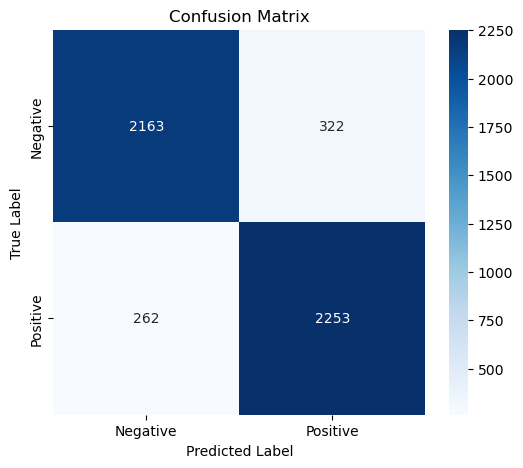

Sentiment: Negative


[codecarbon INFO @ 17:15:42] Energy consumed for RAM : 0.004083 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:15:42] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 17:15:42] Energy consumed for All CPU : 0.017361 kWh
[codecarbon INFO @ 17:15:42] 0.021445 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 17:15:49] Energy consumed for RAM : 0.003875 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:15:49] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 17:15:49] Energy consumed for All CPU : 0.016476 kWh
[codecarbon INFO @ 17:15:49] 0.020351 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 17:15:57] Energy consumed for RAM : 0.004125 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:15:57] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 17:15:57] Energy consumed for All CPU

In [22]:
# TASK 5: Model Evaluation 

# Classification Report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

# Plot the Confusion Matrix

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt= 'd', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
           )
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Test with a new review

review = "The movie had great visuals but the storyline was dull and predictable."

#on va faire le preprocess

processed_review = preprocess_text(review)

#on va utiliser TF-IDF que l'on a déja utiliser plus haut

review_vector = tfidf_vectorizer.transform([processed_review])

#on va faire une prediction

prediction = logreg.predict(review_vector)

#nos résultat

if prediction[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")


6. Hyperparameter Tuning:

    Goal: Optimize your Logistic Regression model by tuning its hyperparameters.
   
    Task: Use an optimization method to find the best parameters for your model and improve its accuracy.

In [28]:
# TASK 6: Hyperparameter Tuning 

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    #'penalty': ['l2']
}

#On va initialiser le modéle en utilisation la regression de tout a l'heure

logreg = LogisticRegression(max_iter=1000)

#Maintenant on passe a GridsearchCV

grid_search = GridSearchCV(
    logreg,
    param_grid,
    cv=10,#on peut jouer avec cette valeur tout les valeurs dans le param_grid
    scoring='accuracy',
    n_jobs=-1
)

# TASK 8: Track emissions during Hyperparameter Tuning

tracker = EmissionsTracker(project_name="IMDB_Hyperparameter_tuning")
tracker.start()

#onn va faire un  entrainement avec GridSearch

grid_search.fit(X_train, y_train)

#on va placer le stop tracking ici 

emissions = tracker.stop()
print(f"CO2 emissions during hyperparameter tuning: {emissions:.6f} kg")

#on va resortir les meilleurs paramètres

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Accuracy:", grid_search.best_score_)

#on va regarder maintenant l'evaluation sur la phase de test

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\nClassification Report (Optimized Model):\n")
print(classification_report(y_test, y_pred_best))


[codecarbon WARNING @ 17:58:34] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:58:34] [setup] RAM Tracking...
[codecarbon INFO @ 17:58:34] [setup] CPU Tracking...
[codecarbon WARNING @ 17:58:34] We saw that you have a 13th Gen Intel(R) Core(TM) i7-13700H but we don't know it. Please contact us.
[codecarbon WARNING @ 17:58:34] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 17:58:34] CPU Model on constant consumption mode: 13th Gen Intel(R) Core(TM) i7-13700H
[codecarbon WARNING @ 17:58:34] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 17:58:34] [setup] GPU Tracking...
[codecarbon INFO @ 17:58:34] No GPU found.
[codecarbon INFO @ 17:58:34] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: globa

CO2 emissions during hyperparameter tuning: 0.000001 kg
Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best Cross-validation Accuracy: 0.8796499999999998

Classification Report (Optimized Model):

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2485
           1       0.88      0.90      0.89      2515

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



7. Learning Curve Analysis:

    Goal: Diagnose your model's performance by plotting learning curves.
   
    Task: Analyze training and validation performance as a function of the training set size to identify underfitting or overfitting issues.


[codecarbon INFO @ 18:08:28] Energy consumed for RAM : 0.012643 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:08:28] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:08:28] Energy consumed for All CPU : 0.053761 kWh
[codecarbon INFO @ 18:08:28] 0.066405 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:08:36] Energy consumed for RAM : 0.002083 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:08:36] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 18:08:36] Energy consumed for All CPU : 0.008859 kWh
[codecarbon INFO @ 18:08:36] 0.010943 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:08:36] Energy consumed for RAM : 0.012894 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:08:36] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 18:08:36] Energy consumed for All CPU

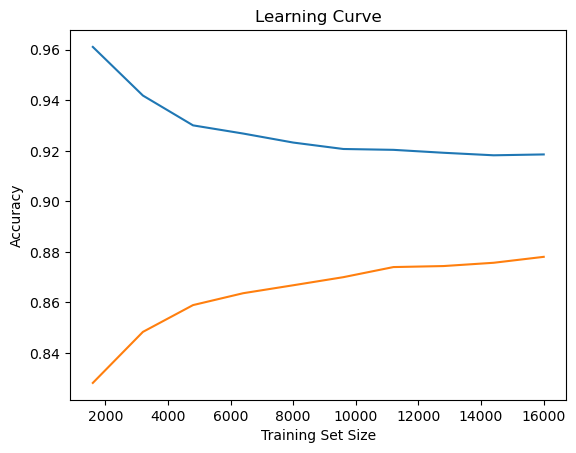

[codecarbon INFO @ 18:08:51] Energy consumed for RAM : 0.002125 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:08:51] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:08:51] Energy consumed for All CPU : 0.009036 kWh
[codecarbon INFO @ 18:08:51] 0.011161 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:08:51] Energy consumed for RAM : 0.012936 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:08:51] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:08:51] Energy consumed for All CPU : 0.055004 kWh
[codecarbon INFO @ 18:08:51] 0.067939 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 18:08:58] Energy consumed for RAM : 0.012727 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 18:08:58] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 18:08:58] Energy consumed for All CPU

In [30]:
# TASK 7: Learning Curve Analysis

#Modéle

model = LogisticRegression(C=1, solver='liblinear', max_iter=1000)

#on va effectuer le calcul des Learning curves
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

#Moyennes
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

#plott
plt.figure()
plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, val_mean)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.show()

9. Ethical Considerations and Explainability:

    Goal: Discuss the ethics in using and deploying your AI-based solution by investigating and implementing suitable explainability methods.
    
    Task: Understanding how a machine learning model makes predictions is crucial for ensuring transparency, fairness, and accountability in AI deployment. One of the widely used techniques for model explainability is SHAP (SHapley Additive exPlanations), which helps determine how much each feature (word) contributes to a prediction.
    In this task, you will use SHAP to analyze the impact of individual words on sentiment classification. This will allow you to visualize which words increase or decrease the probability of a positive or negative sentiment prediction. Additionally, discuss key aspects such as potential biases in the model, fairness in outcomes, and accountability in AI decision-making. You can find more information here: https://shap.readthedocs.io/en/latest/generated/shap.Explanation.html

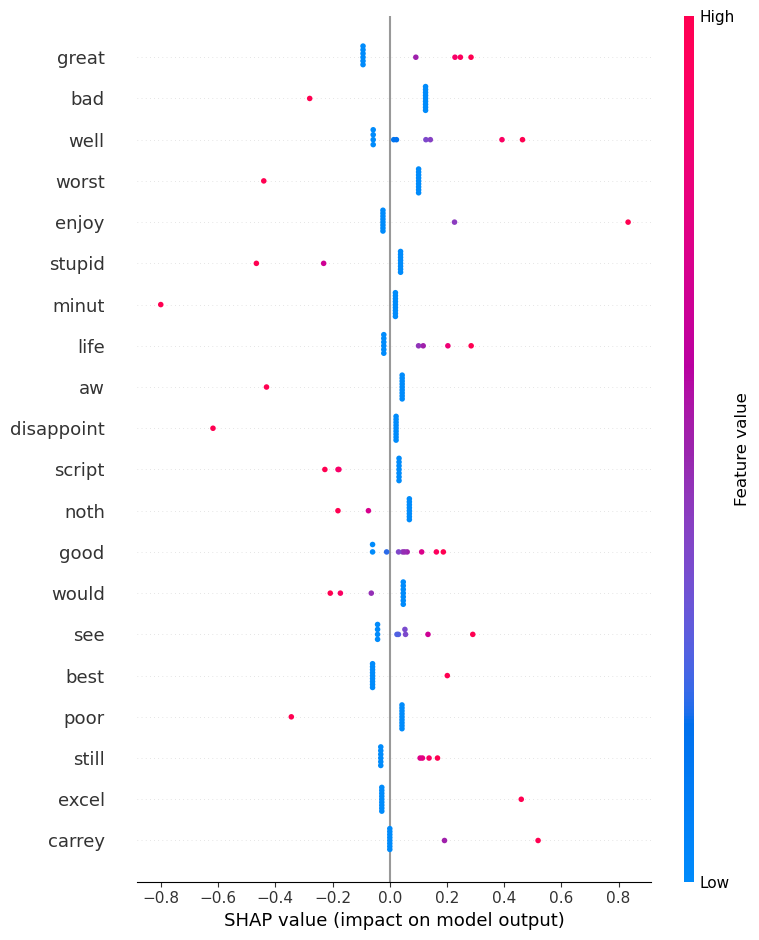

In [8]:
# TASK 9: Ethical Considerations & Explainability

# Show SHAP summary plot with proper feature names


10. Deployment Considerations for Embedded Systems:

    Goal: Optimize and convert the trained logistic regression model for deployment on embedded systems like Arduino
    
    Task: To deploy the trained logistic regression model on a resource-constrained embedded system like an Arduino, we must optimize and convert the model into a format suitable for execution in an environment with limited memory and processing power. Since embedded systems do not support direct execution of machine learning models trained in Python, we extract the model’s learned parameters—namely, the weights and bias—after training. These parameters are then quantized to fixed-point integers to eliminate the need for floating-point calculations, which are inefficient on microcontrollers.
    Once quantization is applied, we generate a C++ .h header file containing the model’s coefficients and bias, formatted in a way that allows direct use within an Arduino sketch. The final model is optimized to perform inference using integer arithmetic, making it both lightweight and efficient for deployment on microcontrollers. You can find more information here: https://medium.com/@thommaskevin/tinyml-binomial-logistic-regression-0fdbf00e6765

In [9]:
# TASK 10: Deployment Considerations (Model Quantization & Export for Arduino)
# Extract weights and bias from the trained logistic regression model

# Apply quantization (convert to fixed-point representation)

# Generate C++ header file for Arduino

# Save the header file


Quantized model parameters saved to sentiment_model.h
